# 3-D Spring–Slider: Stick-Slip on a Frictional Plane

This notebook demonstrates **3-D Coulomb friction** using
`build_impulse_contact` with **two tangential DOFs**.

### Physical setup

A block of mass $m$ sits on a horizontal frictional plane ($z = 0$).
Friction acts in both $x$ and $y$ directions simultaneously — the
contact has **3 reaction DOFs** $(p_N,\, p_{T_x},\, p_{T_y})$
constrained to the second-order cone

$$\sqrt{p_{T_x}^2 + p_{T_y}^2} \;\le\; \mu\, p_N$$

Unlike 2-D friction (single tangential DOF), the 3-D friction cone
**couples** the $x$ and $y$ sliding directions: the *total*
tangential force is limited, not each component independently.

### Stick-slip mechanism

A loading point moves at prescribed velocity (or along a prescribed
path).  A spring connects the loading point to the block.  When the
spring force exceeds the static friction limit $\mu m g$, the block
slips.  Once it catches up, it sticks again until the spring
rebuilds enough force.

### State vector

$$y = (v_x,\; v_y,\; v_z,\; q_x,\; q_y,\; q_z)$$

| Idx | DOF   | Meaning                  |
|-----|-------|--------------------------|
| 0   | $v_x$ | tangential velocity (x)  |
| 1   | $v_y$ | tangential velocity (y)  |
| 2   | $v_z$ | normal velocity          |
| 3   | $q_x$ | tangential position (x)  |
| 4   | $q_y$ | tangential position (y)  |
| 5   | $q_z$ | normal position (gap)    |

Gravity is carried by the cone offset `s0 = m·g·h` (not in the RHS).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from solve_nivp.contact import build_impulse_contact
import solve_nivp


## Part 1 — Linear drive: classic stick-slip

The loading point moves at constant velocity $v_{\text{drive}}$ in the
$x$-direction.  A spring of stiffness $k$ connects it to the block:

$$F_x = k\,(v_{\text{drive}}\, t - q_x)$$

**Stick phase:** block is stationary, spring stretches at rate
$v_{\text{drive}}$.

**Slip phase:** spring force exceeds $\mu m g$ → block accelerates,
overshoots slightly, then re-sticks.

The $y$-direction is quiescent (no driving), but the **3-D friction
cone** is fully operational — both tangential DOFs participate in
the projection.


In [2]:
# ── Physical parameters ──
mass    = 1.0        # [kg]
g       = 9.81       # [m/s²]
mu      = 0.5        # Coulomb friction coefficient
k       = 80.0       # spring stiffness [N/m]
v_drive = 0.04       # loading-point velocity [m/s]  (slow → clean sticking)

h_fixed   = 0.001    # initial step size [s]
t_span_lin = (0.0, 12.0)

friction_limit = mu * mass * g
omega_n = np.sqrt(k / mass)
print(f"Friction limit  = μ·m·g = {friction_limit:.3f} N")
print(f"Slip stretch    = {friction_limit / k:.4f} m")
print(f"Approx. period  ≈ {friction_limit / k / v_drive:.2f} s")
print(f"Natural freq    = √(k/m) = {omega_n:.2f} rad/s")
print(f"Stick-slip ratio v·ω/(μg) = {v_drive * omega_n / (mu*g):.3f}  (< 0.1 → clean stick-slip)\n")

# ── Mutable step-size reference (updated by rhs_aug) ──
_h = [h_fixed]

# ── 6×6 descriptor: A = diag(m, m, m, 1, 1, 1) ──
A_phys = np.diag([mass, mass, mass, 1.0, 1.0, 1.0])

def rhs_linear(t, y):
    """Smooth RHS: spring pulling in x, kinematics, no gravity."""
    v_x, v_y, v_z = y[0], y[1], y[2]
    q_x = y[3]
    x_load = v_drive * t
    return np.array([
        k * (x_load - q_x),    # spring force in x  [N]
        0.0,                    # no y-force
        0.0,                    # normal: gravity via s0
        v_x,                    # kinematics
        v_y,
        v_z,
    ])

# Always-active contact (gravity carried by s0, not RHS)
gap_func = lambda y, t: np.array([-1.0])

# Physical IC: block at origin, at rest
y0_lin = np.zeros(6)

# ── Build augmented system ──
# 3-D contact: vel_tangential_idx=[0, 1] → 2 tangential DOFs
cs_lin = build_impulse_contact(
    A=A_phys,
    rhs_smooth=rhs_linear,
    y0=y0_lin,
    contacts=[dict(vel_normal_idx=2, vel_tangential_idx=[0, 1], mu=mu)],
    gap_func=gap_func,
    component_slices=[slice(0, 3), slice(3, 6)],
    get_s0=lambda y: mass * g * _h[0],
    step_size_ref=_h,
)

print(f"Augmented state: {len(cs_lin.y0)} DOFs "
      f"(6 physical + {len(cs_lin.y0) - 6} reaction)")

# ── Solve ──
t_lin, y_lin, h_lin, fk_lin, info_lin = solve_nivp.solve_ivp_ns(
    fun=cs_lin.rhs,
    t_span=t_span_lin,
    y0=cs_lin.y0,
    A=cs_lin.A,
    method='backward_euler',
    projection=cs_lin.projection,
    solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs_lin.component_slices,
    integrator_opts=cs_lin.integrator_opts,
    adaptive=True,
    h0=h_fixed,
)

n_phys = cs_lin.n_phys
print(f"\nSolved: {len(t_lin)} steps, final q_x = {y_lin[-1, 3]:.4f} m")
print(f"Loading point at t={t_span_lin[1]:.0f}: x_load = {v_drive * t_span_lin[1]:.2f} m")

Friction limit  = μ·m·g = 4.905 N
Slip stretch    = 0.0613 m
Approx. period  ≈ 1.53 s
Natural freq    = √(k/m) = 8.94 rad/s
Stick-slip ratio v·ω/(μg) = 0.073  (< 0.1 → clean stick-slip)

Augmented state: 9 DOFs (6 physical + 3 reaction)

Solved: 425 steps, final q_x = 0.4187 m
Loading point at t=12: x_load = 0.48 m


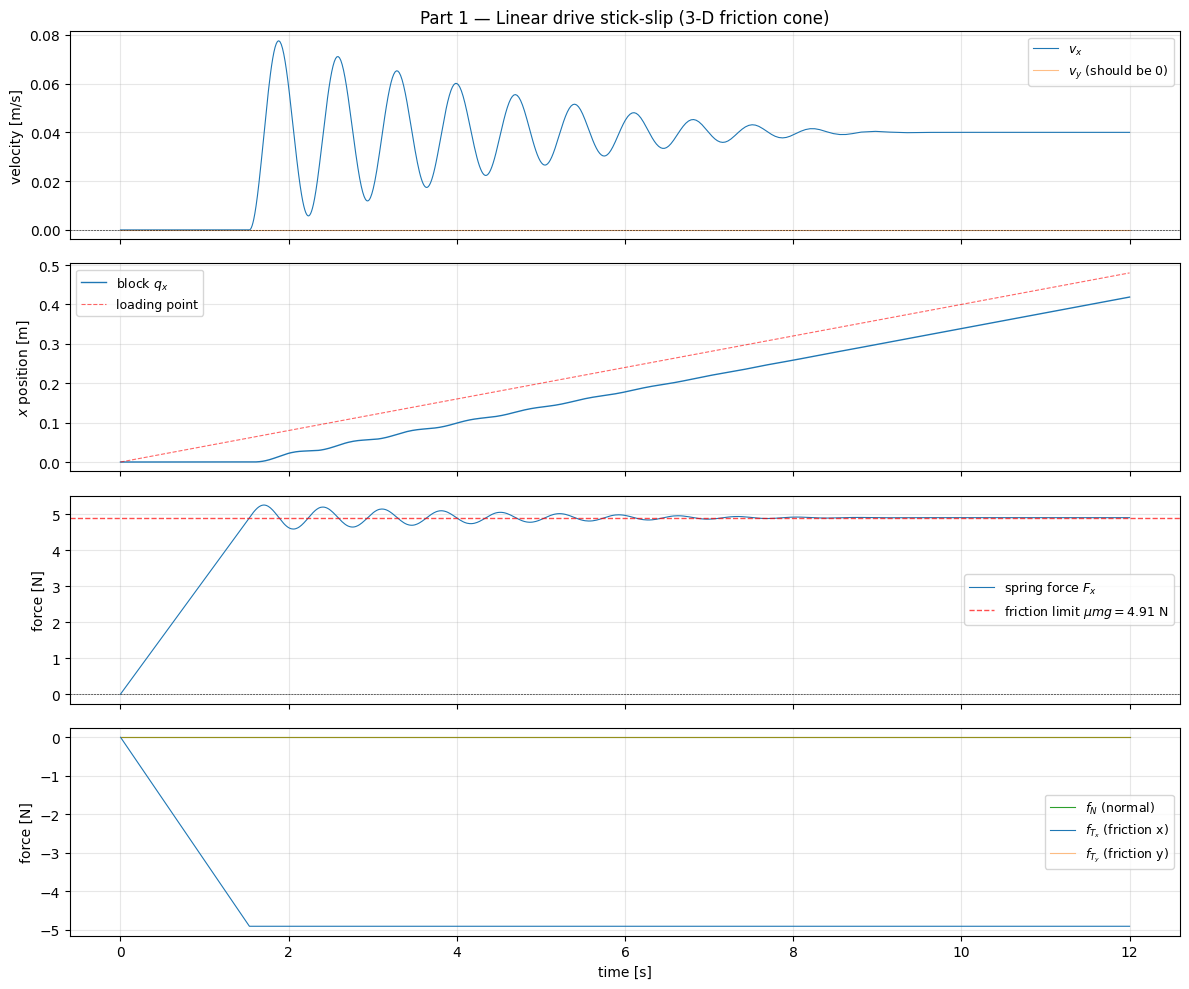

In [12]:
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# (a) Velocity
axs[0].plot(t_lin, y_lin[:, 0], 'C0-', lw=0.8, label='$v_x$')
axs[0].plot(t_lin, y_lin[:, 1], 'C1-', lw=0.8, alpha=0.5, label='$v_y$ (should be 0)')
axs[0].axhline(0, color='k', lw=0.4, ls='--')
axs[0].set_ylabel('velocity [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title('Part 1 — Linear drive stick-slip (3-D friction cone)')
axs[0].grid(True, alpha=0.3)

# (b) Position vs loading point
x_load = v_drive * t_lin
axs[1].plot(t_lin, y_lin[:, 3], 'C0-', lw=1.0, label='block $q_x$')
axs[1].plot(t_lin, x_load, 'r--', lw=0.8, alpha=0.6, label='loading point')
axs[1].set_ylabel('$x$ position [m]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

# (c) Spring force vs friction limit
F_spring = k * (x_load - y_lin[:, 3])
axs[2].plot(t_lin, F_spring, 'C0-', lw=0.8, label='spring force $F_x$')
axs[2].axhline(friction_limit, color='r', ls='--', lw=1, alpha=0.7,
               label=f'friction limit $\mu mg = {friction_limit:.2f}$ N')
axs[2].axhline(0, color='k', lw=0.4, ls='--')
axs[2].set_ylabel('force [N]')
axs[2].legend(fontsize=9)
axs[2].grid(True, alpha=0.3)

# (d) Contact impulses / h_int → forces
# Richardson half-step correction: stored impulses span h/2
h_arr = np.diff(t_lin)
h_int = h_arr / 2.0
axs[3].plot(t_lin[1:], y_lin[1:, n_phys] / h_int, 'C2-', lw=0.8,
            label='$f_N$ (normal)')
axs[3].plot(t_lin[1:], y_lin[1:, n_phys+1] / h_int, 'C0-', lw=0.8,
            label='$f_{T_x}$ (friction x)')
axs[3].plot(t_lin[1:], y_lin[1:, n_phys+2] / h_int, 'C1-', lw=0.8,
            alpha=0.5, label='$f_{T_y}$ (friction y)')
axs[3].set_ylabel('force [N]')
axs[3].set_xlabel('time [s]')
axs[3].legend(fontsize=9)
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Zooming in on a single stick-slip cycle

During **stick**, $v_x = 0$ and the spring force ramps linearly:
$F = k \cdot v_{\text{drive}} \cdot \Delta t$.

At **slip onset**, $F = \mu m g$.  The block accelerates, overshoots,
and re-sticks when the spring relaxes below the friction limit.


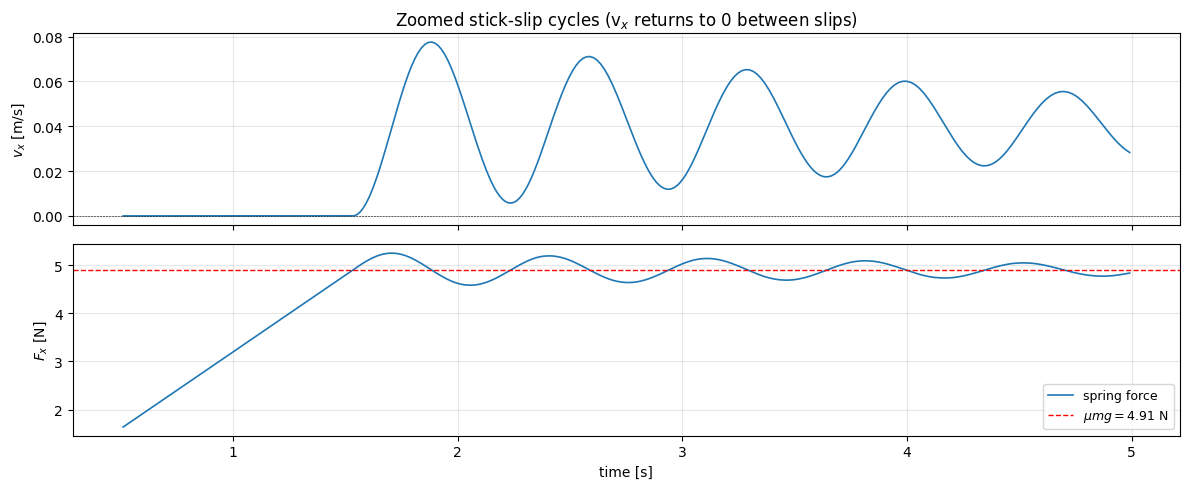

In [9]:
# Zoom into the first few clear stick-slip cycles
t_lo, t_hi = 0.5, 5.0

mask = (t_lin >= t_lo) & (t_lin <= t_hi)

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axs[0].plot(t_lin[mask], y_lin[mask, 0], 'C0-', lw=1.2)
axs[0].axhline(0, color='k', lw=0.4, ls='--')
axs[0].set_ylabel('$v_x$ [m/s]')
axs[0].set_title('Zoomed stick-slip cycles (v$_x$ returns to 0 between slips)')
axs[0].grid(True, alpha=0.3)

F_sp_z = k * (v_drive * t_lin[mask] - y_lin[mask, 3])
axs[1].plot(t_lin[mask], F_sp_z, 'C0-', lw=1.2, label='spring force')
axs[1].axhline(friction_limit, color='r', ls='--', lw=1,
               label=f'$\\mu m g = {friction_limit:.2f}$ N')
axs[1].set_ylabel('$F_x$ [N]')
axs[1].set_xlabel('time [s]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2 — Circular drive: 2-D stick-slip

Now the loading point traces a **circle** on the $x$-$y$ plane:

$$x_L(t) = R\cos(\omega t),\qquad y_L(t) = R\sin(\omega t)$$

Springs in both $x$ and $y$ connect it to the block:

$$F_x = k\,(x_L - q_x),\qquad F_y = k\,(y_L - q_y)$$

The block tries to follow the circle.  But friction limits the
**total tangential force**: $\sqrt{F_x^2 + F_y^2} \le \mu m g$.

This exercises the full 3-D friction cone — sliding direction
depends on the instantaneous force direction, and the $x$ and
$y$ components are **coupled** through the cone constraint.

The block traces a **smaller, jagged version** of the loading circle,
with intermittent stick-slip events.


In [3]:
# ── Circular drive parameters ──
R     = 0.3                    # circle radius [m]
omega = 2 * np.pi / 15.0      # angular velocity [rad/s]  (period = 15 s)
k_c   = 40.0                  # spring stiffness [N/m]

t_span_circ = (0.0, 30.0)     # two full revolutions

speed_load = R * omega
slip_stretch = friction_limit / k_c

print(f"Loading speed   = Rω = {speed_load:.4f} m/s")
print(f"Friction limit  = {friction_limit:.3f} N")
print(f"Slip stretch    = {slip_stretch:.4f} m  ({slip_stretch/R*100:.0f}% of R)")
print(f"Circle period   = {2*np.pi/omega:.1f} s")
print(f"Stick-slip ratio = {speed_load * np.sqrt(k_c/mass) / (mu*g):.3f}\n")

def rhs_circular(t, y):
    """Smooth RHS: 2-D spring toward a circularly moving loading point."""
    v_x, v_y, v_z = y[0], y[1], y[2]
    q_x, q_y = y[3], y[4]
    x_L = R * np.cos(omega * t)
    y_L = R * np.sin(omega * t)
    return np.array([
        k_c * (x_L - q_x),    # spring x
        k_c * (y_L - q_y),    # spring y
        0.0,                    # normal
        v_x,
        v_y,
        v_z,
    ])

# Start block at loading point's initial position (R, 0) → zero spring force
y0_circ = np.zeros(6)
y0_circ[3] = R   # q_x = R

cs_circ = build_impulse_contact(
    A=A_phys,
    rhs_smooth=rhs_circular,
    y0=y0_circ,
    contacts=[dict(vel_normal_idx=2, vel_tangential_idx=[0, 1], mu=mu)],
    gap_func=gap_func,
    component_slices=[slice(0, 3), slice(3, 6)],
    get_s0=lambda y: mass * g * _h[0],
    step_size_ref=_h,
)

t_circ, y_circ, h_circ, fk_circ, info_circ = solve_nivp.solve_ivp_ns(
    fun=cs_circ.rhs,
    t_span=t_span_circ,
    y0=cs_circ.y0,
    A=cs_circ.A,
    method='backward_euler',
    projection=cs_circ.projection,
    solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs_circ.component_slices,
    integrator_opts=cs_circ.integrator_opts,
    adaptive=True,
    h0=h_fixed,
)

print(f"Solved: {len(t_circ)} steps")
print(f"Final block pos: ({y_circ[-1, 3]:.4f}, {y_circ[-1, 4]:.4f})")
print(f"Final load  pos: ({R*np.cos(omega*t_span_circ[1]):.4f}, "
      f"{R*np.sin(omega*t_span_circ[1]):.4f})")

Loading speed   = Rω = 0.1257 m/s
Friction limit  = 4.905 N
Slip stretch    = 0.1226 m  (41% of R)
Circle period   = 15.0 s
Stick-slip ratio = 0.162

Solved: 850 steps
Final block pos: (0.2496, -0.1118)
Final load  pos: (0.3000, -0.0000)


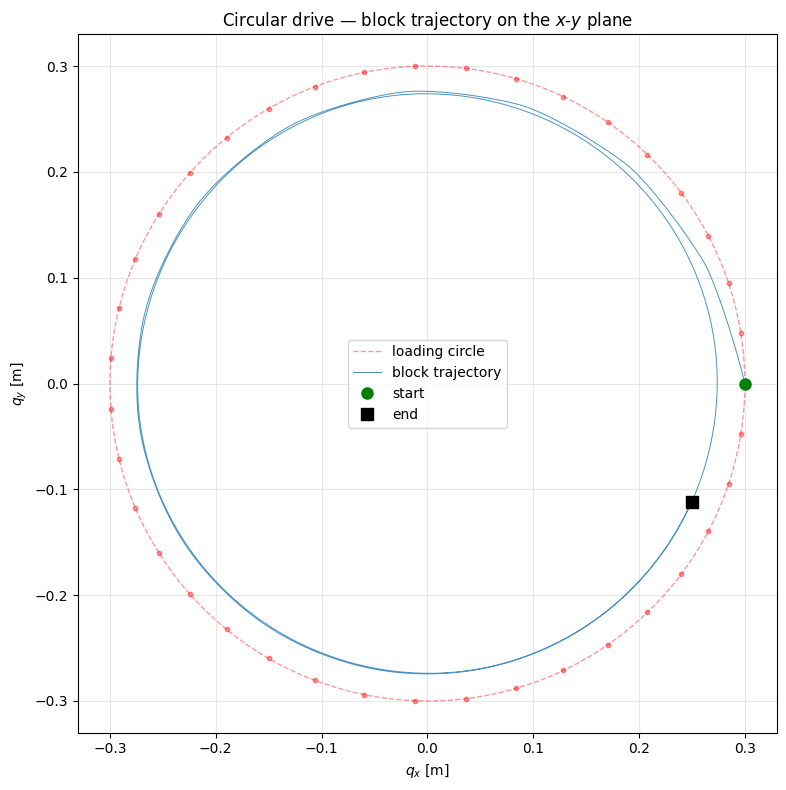

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

# Loading point circle
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(R * np.cos(theta), R * np.sin(theta), 'r--', lw=1, alpha=0.4,
        label='loading circle')

# Loading point position over time (dots at regular intervals)
t_dots = np.linspace(t_span_circ[0], t_span_circ[1], 40)
ax.scatter(R * np.cos(omega * t_dots), R * np.sin(omega * t_dots),
           c='r', s=10, alpha=0.4, zorder=3)

# Block trajectory
ax.plot(y_circ[:, 3], y_circ[:, 4], 'C0-', lw=0.7, alpha=0.8,
        label='block trajectory')
ax.plot(y_circ[0, 3], y_circ[0, 4], 'go', ms=8, zorder=5, label='start')
ax.plot(y_circ[-1, 3], y_circ[-1, 4], 'ks', ms=8, zorder=5, label='end')

ax.set(xlabel='$q_x$ [m]', ylabel='$q_y$ [m]',
       title='Circular drive — block trajectory on the $x$-$y$ plane',
       aspect='equal')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


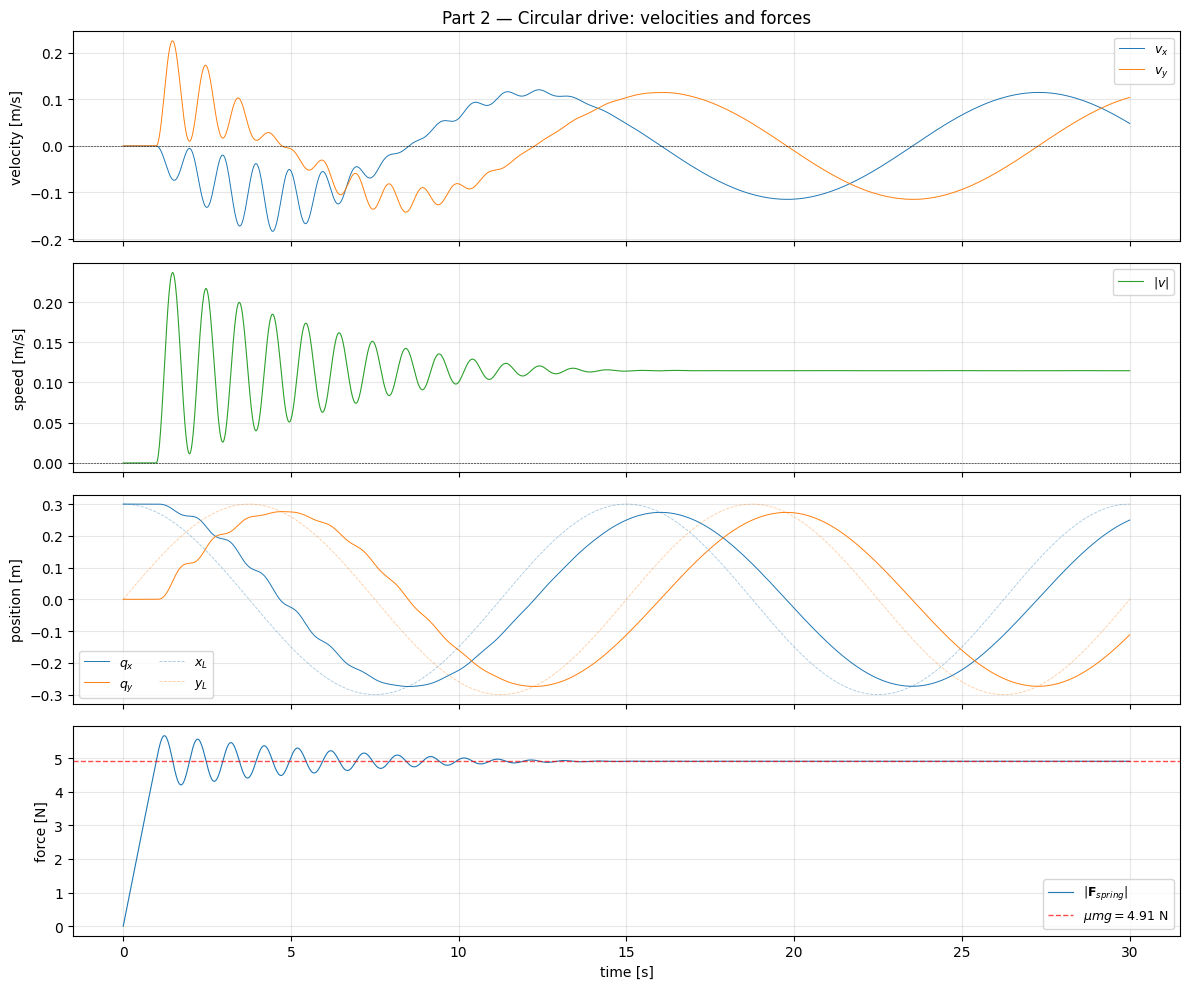

In [14]:
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# (a) Velocities
axs[0].plot(t_circ, y_circ[:, 0], 'C0-', lw=0.7, label='$v_x$')
axs[0].plot(t_circ, y_circ[:, 1], 'C1-', lw=0.7, label='$v_y$')
axs[0].axhline(0, color='k', lw=0.4, ls='--')
axs[0].set_ylabel('velocity [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title('Part 2 — Circular drive: velocities and forces')
axs[0].grid(True, alpha=0.3)

# (b) Speed
speed = np.sqrt(y_circ[:, 0]**2 + y_circ[:, 1]**2)
axs[1].plot(t_circ, speed, 'C2-', lw=0.8, label='$|v|$')
axs[1].axhline(0, color='k', lw=0.4, ls='--')
axs[1].set_ylabel('speed [m/s]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

# (c) Positions
axs[2].plot(t_circ, y_circ[:, 3], 'C0-', lw=0.7, label='$q_x$')
axs[2].plot(t_circ, y_circ[:, 4], 'C1-', lw=0.7, label='$q_y$')
x_L_t = R * np.cos(omega * t_circ)
y_L_t = R * np.sin(omega * t_circ)
axs[2].plot(t_circ, x_L_t, 'C0--', lw=0.6, alpha=0.4, label='$x_L$')
axs[2].plot(t_circ, y_L_t, 'C1--', lw=0.6, alpha=0.4, label='$y_L$')
axs[2].set_ylabel('position [m]')
axs[2].legend(fontsize=9, ncol=2)
axs[2].grid(True, alpha=0.3)

# (d) Spring force magnitude vs friction limit
Fx = k_c * (x_L_t - y_circ[:, 3])
Fy = k_c * (y_L_t - y_circ[:, 4])
F_mag = np.sqrt(Fx**2 + Fy**2)
axs[3].plot(t_circ, F_mag, 'C0-', lw=0.8,
            label='$|\mathbf{F}_{spring}|$')
axs[3].axhline(friction_limit, color='r', ls='--', lw=1, alpha=0.7,
               label=f'$\mu mg = {friction_limit:.2f}$ N')
axs[3].set_ylabel('force [N]')
axs[3].set_xlabel('time [s]')
axs[3].legend(fontsize=9)
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Friction cone in action

During **stick**, the spring force builds up but remains inside
the friction cone.  At **slip**, the force point hits the cone
boundary and the block slides in the direction of the force.

The plot below shows the friction force components $(p_{T_x}/h,\,
p_{T_y}/h)$ overlaid with the friction cone circle $\mu m g$.


In [13]:
import plotly.graph_objects as go

# ── Friction force trajectory (impulse / h_internal → force) ──
# The adaptive integrator uses Richardson extrapolation: the stored
# reaction impulses come from the *last half-step* of size h/2.
# The physical force is therefore  r / (h/2) = 2r / h.
h_arr_c = np.diff(t_circ)
h_internal = h_arr_c / 2.0        # Richardson half-step

fTx = y_circ[1:, n_phys + 1] / h_internal
fTy = y_circ[1:, n_phys + 2] / h_internal
fN  = y_circ[1:, n_phys]     / h_internal

# Effective normal force includes s0/h = mg (gravity carried by cone offset)
fN_eff = fN + mass * g    # p_N^eff / h_int = p_N/h_int + mg

# ── Cone surface: √(fTx² + fTy²) = μ · fN_eff ──
pN_max = fN_eff.max() * 1.3
pN_grid = np.linspace(0, pN_max, 60)
theta_grid = np.linspace(0, 2 * np.pi, 80)
pN_mesh, Th = np.meshgrid(pN_grid, theta_grid)
pTx_cone = mu * pN_mesh * np.cos(Th)
pTy_cone = mu * pN_mesh * np.sin(Th)

fig3d = go.Figure()

# Cone surface
fig3d.add_trace(go.Surface(
    x=pTx_cone, y=pTy_cone, z=pN_mesh,
    colorscale=[[0, 'rgba(255,100,100,0.12)'], [1, 'rgba(255,50,50,0.22)']],
    showscale=False,
    name='friction cone',
    hovertemplate='f_Tx: %{x:.2f} N<br>f_Ty: %{y:.2f} N<br>f_N_eff: %{z:.2f} N',
))

# Friction force trajectory coloured by time
fig3d.add_trace(go.Scatter3d(
    x=fTx, y=fTy, z=fN_eff,
    mode='markers+lines',
    line=dict(color=t_circ[1:], colorscale='Viridis', width=3),
    marker=dict(
        size=2.5,
        color=t_circ[1:],
        colorscale='Viridis',
        colorbar=dict(title='time [s]', x=1.02),
    ),
    name='friction force',
    hovertemplate=(
        'f_Tx: %{x:.3f} N<br>'
        'f_Ty: %{y:.3f} N<br>'
        'f_N_eff: %{z:.3f} N<br>'
        '<extra></extra>'
    ),
))

# Cone boundary circle at the effective normal force level fN_eff = mg
# This is where sliding happens: √(fTx² + fTy²) = μ·mg
theta_c = np.linspace(0, 2*np.pi, 200)
pN_eff_level = mass * g
fig3d.add_trace(go.Scatter3d(
    x=mu * pN_eff_level * np.cos(theta_c),
    y=mu * pN_eff_level * np.sin(theta_c),
    z=np.full_like(theta_c, pN_eff_level),
    mode='lines',
    line=dict(color='red', width=4),
    name=f'sliding limit at f_N_eff = mg',
))

fig3d.update_layout(
    scene=dict(
        xaxis_title='f_Tx  [N]',
        yaxis_title='f_Ty  [N]',
        zaxis_title='f_N_eff  [N]  (= f_N + mg)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1.2),
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.9)),
    ),
    title='3-D Friction Cone — interactive<br>'
          '<sup>Effective normal force includes gravity (s₀).  '
          f'Cone: √(f_Tx² + f_Ty²) ≤ μ·f_N_eff,  μ = {mu}</sup>',
    width=750, height=700,
    margin=dict(l=0, r=0, t=60, b=0),
)

fig3d.show()

## Summary

| Feature | Part 1 (linear) | Part 2 (circular) |
|---------|-----------------|-------------------|
| Tangential DOFs | 2 ($v_x, v_y$) | 2 ($v_x, v_y$) |
| Active DOFs | 1 ($x$ only) | 2 ($x$ and $y$) |
| Slip direction | always $+x$ | rotates with load |
| Friction cone | 1-D slice of 3-D cone | fully exercised |
| Steady state | block follows at $v_{\text{drive}}$ | block traces lagging circle |

**Key takeaway:** the 3-D friction cone couples the tangential
directions — friction in $x$ reduces the available friction in
$y$ and vice versa.  The circular drive makes this coupling
physically visible: the block lags behind the loading point
because friction limits the *total* tangential force
$\sqrt{F_x^2 + F_y^2} \le \mu m g$, not each component separately.

### Stick-slip dynamics

With pure Coulomb friction (equal static and kinetic $\mu$),
the initial cycles show clear stick-slip:

1. **Stick:** block is stationary, spring force ramps linearly.
2. **Slip:** spring force exceeds $\mu m g$, block accelerates.
3. **Re-stick:** spring relaxes, block decelerates to rest.

After several cycles the oscillation amplitude decays and the
block transitions to **steady sliding** at the loading velocity.
The number of visible stick-slip cycles depends on the
*stick-slip ratio* $v_{\text{drive}} \omega_0 / (\mu g)$:
smaller values give more and cleaner cycles.

### API used

```python
contacts=[dict(
    vel_normal_idx=2,            # v_z is the normal velocity
    vel_tangential_idx=[0, 1],   # v_x, v_y are tangential  →  3-D cone
    mu=mu,
)]
```

Setting `vel_tangential_idx` to a **2-element list** is all that
is needed to switch from 2-D (1 tangential DOF) to 3-D friction.